In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load Genes

In [2]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 132 ms, sys: 19.9 ms, total: 152 ms
Wall time: 152 ms


# Load data

In [3]:
%%time

# Load and aggregate pseudotime data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"
sdata = sc.read_h5ad(fpath)

sdata.X = sdata.layers['raw_counts'].copy()
sdata.obs['cell_type'] = sdata.obs['group'].copy()
sdata = sdata[sdata.obs['cell_type'].notna()].copy()
sdata = sc.get.aggregate(sdata, by='cell_type', func='sum')
sdata.X = sdata.layers['sum']
sdata.obs['group'] = 'sample'

# Load and preprocess reference data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"
rdata = sc.read_h5ad(fpath)
rdata.obs['group'] = 'atlas'

# Concatenate and return
adata = an.concat([sdata, rdata], join='outer', axis=0)
adata

CPU times: user 3 s, sys: 6.64 s, total: 9.65 s
Wall time: 13 s


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group'
    layers: 'sum'

In [4]:
adata.obs['group'].value_counts(dropna=False)

group
atlas     188
sample      4
Name: count, dtype: int64

In [5]:
def load_label_map_at_level(file_path: str, level: str) -> dict:
    """Reads YAML, mapping labels to a specific level, with a fallback."""
    with open(file_path, 'r') as f:
        full_data = yaml.safe_load(f)

    label_map = {}
    for label, data in full_data.items():
        if not isinstance(data, dict):
            continue
        
        # Use the requested level's value if it exists.
        value = data.get(level)

        # If it doesn't exist, find the highest available level and use its value.
        if value is None:
            # max() on ['level1', 'level2'] correctly returns 'level2'.
            # The default prevents an error if no 'level' keys are found.
            highest_level_key = max([k for k in data if str(k).startswith('level')], default=None)
            if highest_level_key:
                value = data.get(highest_level_key)
        
        # Only add entries that have a valid level annotation.
        if value is not None:
            label_map[label] = value
            
    return label_map
    

fpath = "../../resources/cell_labels.yaml"

levels = ['level1', 'level2', 'level3', 'level4']
label_maps = {}
for label in levels:
    label_map = load_label_map_at_level(fpath, label)
    adata.obs[label] = adata.obs['cell_type'].map(label_map)
    adata.obs[label] = np.where(adata.obs[label].isna(), adata.obs['cell_type'], adata.obs[label])
    print(f"{label} {adata.obs[label].nunique()} labels")
    label_maps[label] = label_map

adata

level1 6 labels
level2 12 labels
level3 38 labels
level4 71 labels


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4'
    layers: 'sum'

# Score Cell Cycle

In [6]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 123 ms, sys: 43.4 ms, total: 166 ms
Wall time: 166 ms


,cell_type,group,level1,level2,level3,level4,S_score,G2M_score,phase
bm_other,bm_other,sample,bm_other,bm_other,bm_other,bm_other,-1386.722751,-398.909691,G1
intial,intial,sample,intial,intial,intial,intial,-3194.695767,9187.677225,G2M
reprogram,reprogram,sample,reprogram,reprogram,reprogram,reprogram,-5407.482540,-4941.945890,G1
target,target,sample,target,target,target,target,-1581.116402,-1449.989065,G1
B-1 B cell,B-1 B cell,atlas,Hematopoietic,Lymphoid,B Cell,B-1 B Cell,-130.081530,-109.802342,G1


# Gene Filtering


In [7]:
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(int)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")

adata

adata.X.shape=(192, 35595)
type(adata.X)=<class 'numpy.ndarray'>


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4', 'S_score', 'G2M_score', 'phase'
    layers: 'sum'

In [8]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

rsc.get.anndata_to_CPU(adata)
print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
False    19464
True     16131


# scvi

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib ...
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_mat

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 39258.961. Signaling Trainer to stop.


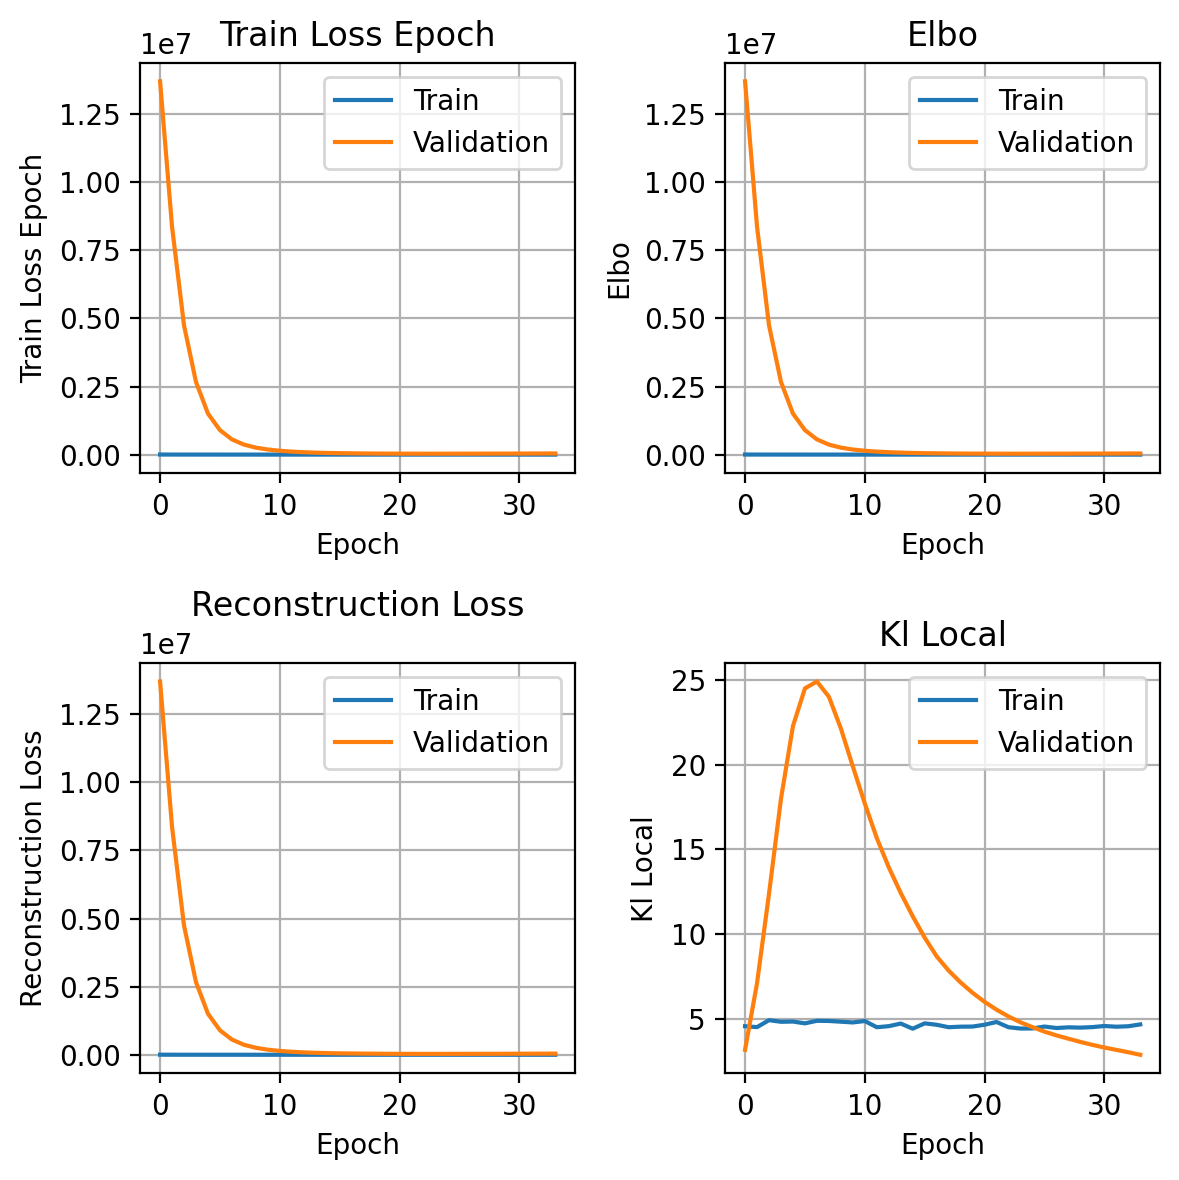

CPU times: user 1.5 s, sys: 248 ms, total: 1.75 s
Wall time: 1.86 s


In [9]:
%%time
batch_key = "group"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=1500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=1000,
    accelerator='gpu',
    early_stopping_patience=10,
    early_stopping=True,
    batch_size=2 ** 14,
    train_size=0.8,
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

[2025-07-03 13:22:45.607] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization


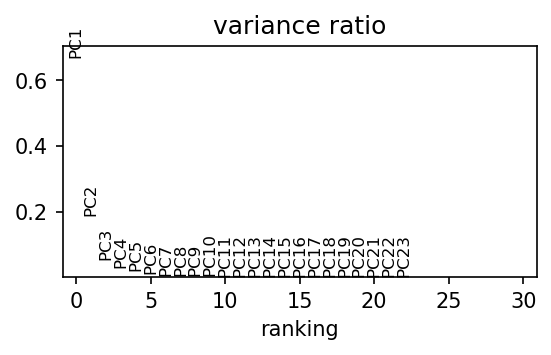

[2025-07-03 13:22:45.883] [CUML] [debug] n_neighbors=10
[2025-07-03 13:22:45.883] [CUML] [debug] Calling knn graph run
[2025-07-03 13:22:45.883] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-07-03 13:22:45.896] [CUML] [debug] Done. Calling remove zeros


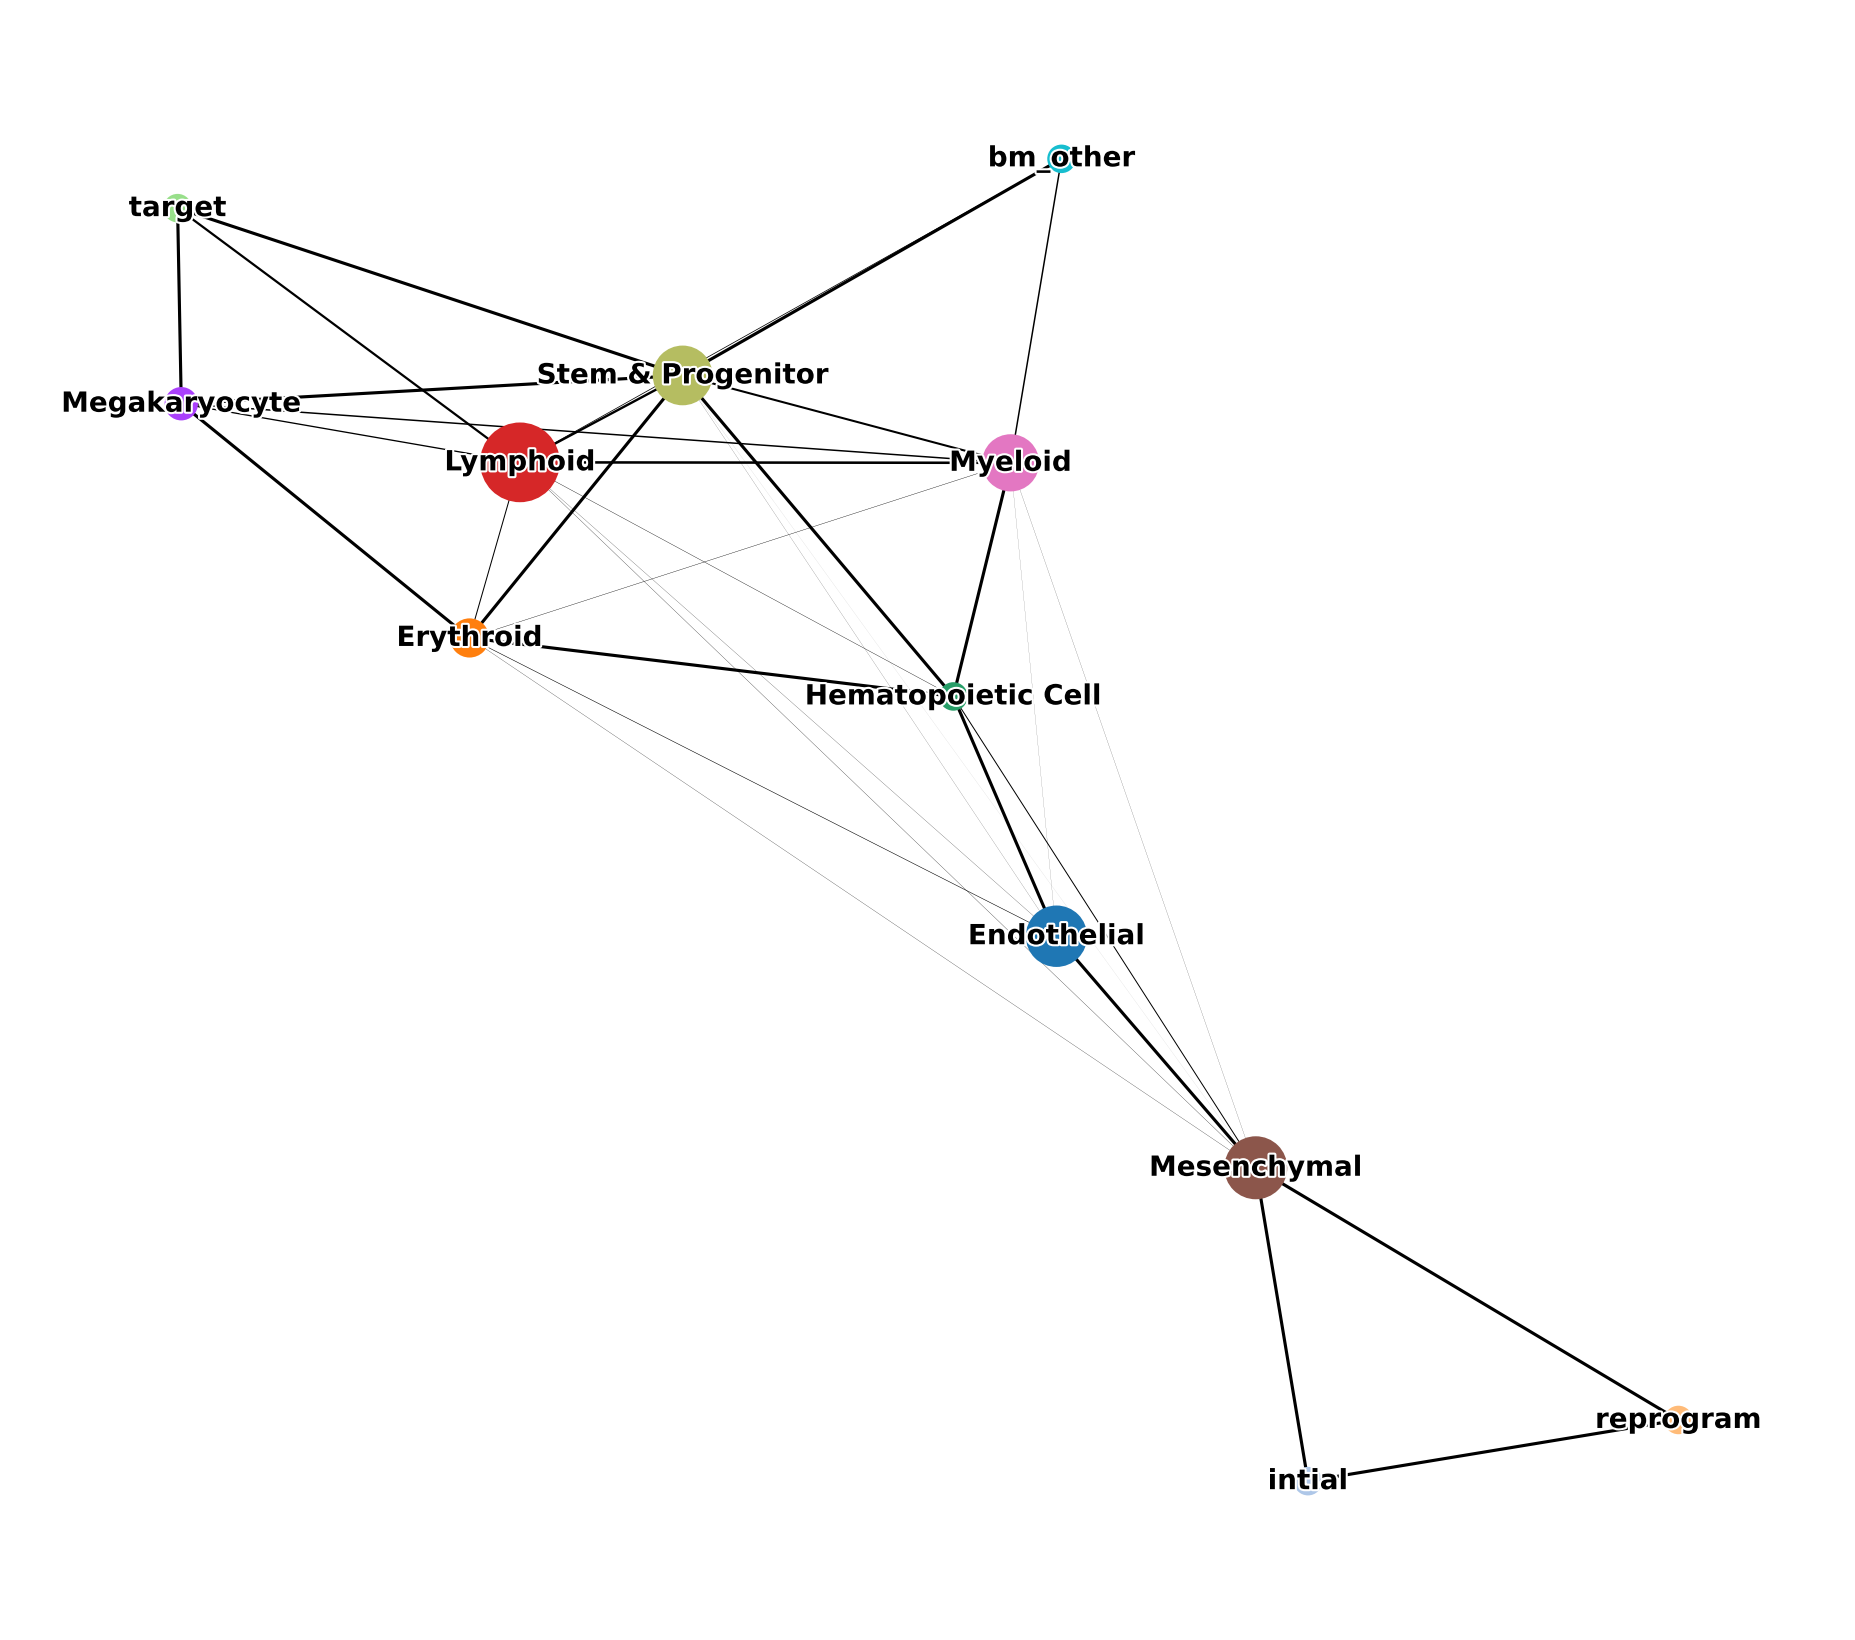

CPU times: user 419 ms, sys: 136 ms, total: 555 ms
Wall time: 562 ms


In [10]:
%%time 

n_neighbors = 10
paga_group_column = "level2"
n_pcs = 50

"""
PAGA
"""
embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)
rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.15,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

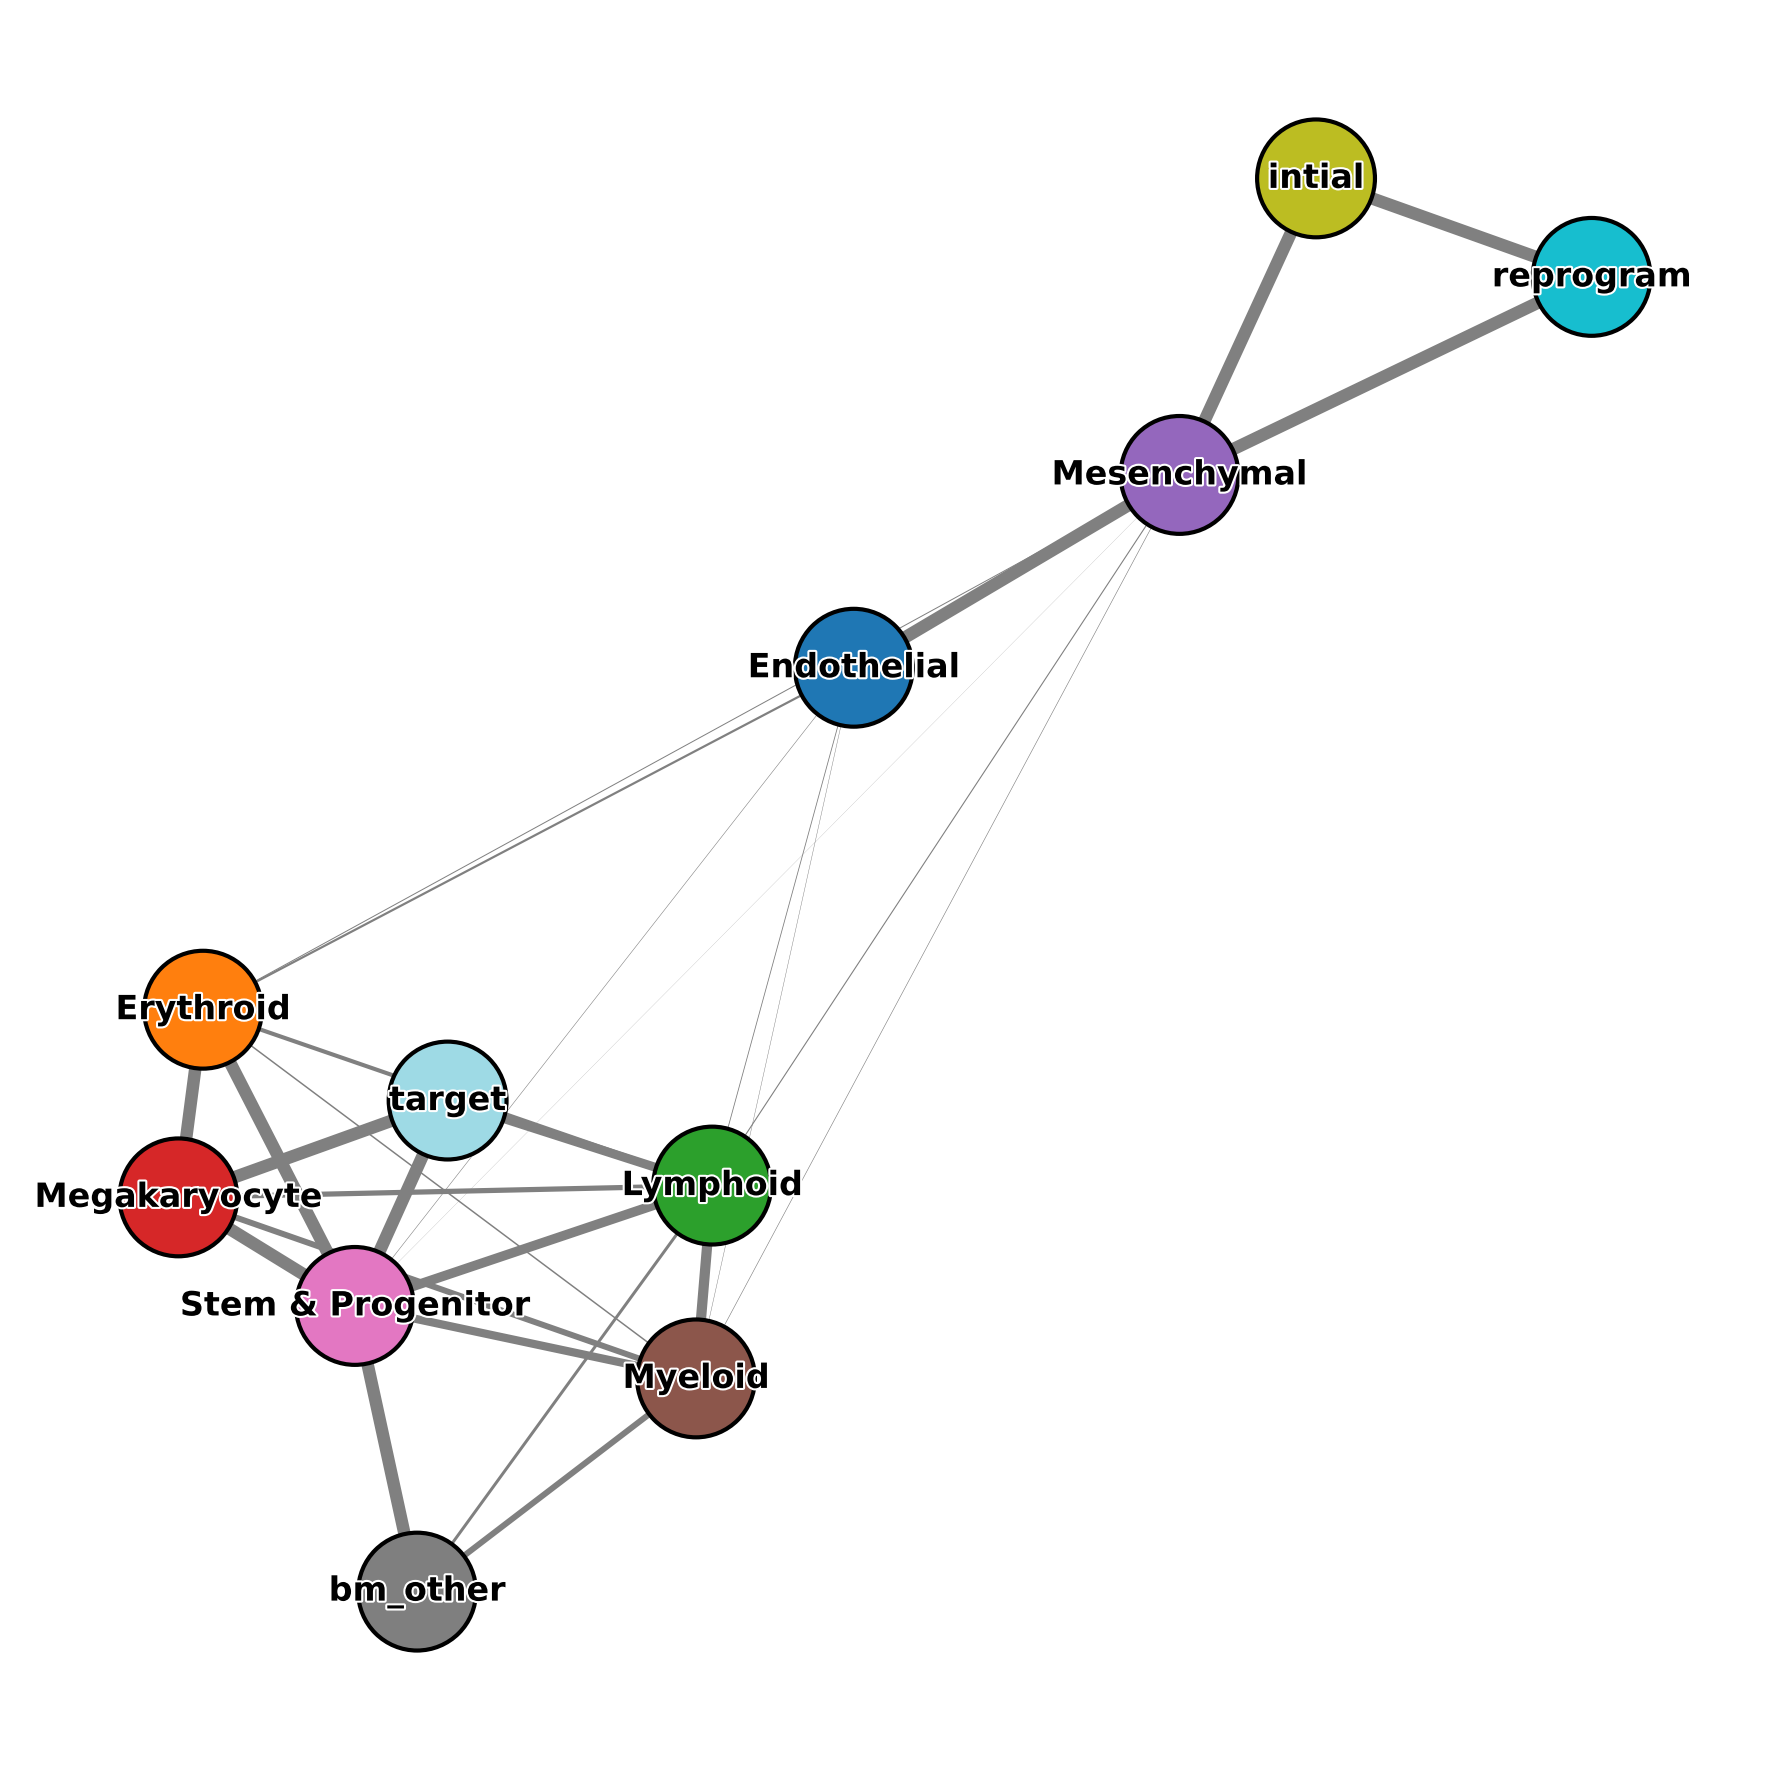

In [14]:
def paga_to_networkx(adata):
    """
    Build a NetworkX graph from adata.uns['paga'].
    
        
    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph (nodes = clusters, edges = PAGA connectivity).
    """
    # Get PAGA connectivity and cluster names
    conn = adata.uns['paga']['connectivities']
    group_key = adata.uns['paga']['groups']
    clusters = adata.obs[group_key].cat.categories

    matrix = pd.DataFrame(
        adata.uns['paga']['connectivities'].todense().copy(),
        index=clusters.values,
        columns=clusters.values,
    )

    G = nx.from_pandas_adjacency(matrix)
    G.pos = adata.uns['paga']['pos'].copy()
    return G

G = paga_to_networkx(embed)
G.remove_node('Hematopoietic Cell')

# Node colors: one color per node
node_colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes)))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

# Plot
pos = nx.spring_layout(G, seed=0)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='grey', width=3*np.array(weights))
nx.draw_networkx_nodes(
    G, pos, 
    node_color=node_colors, 
    node_size=800, 
    edgecolors='black',   # node outline
    linewidths=1
)

# Draw labels with white border (stroke)
label_dict = {n: n for n in G.nodes}
labels = nx.draw_networkx_labels(
    G, pos, labels=label_dict, font_size=8, font_weight='bold',
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
plt.tight_layout()
plt.show()